# Análise consolidada — Prompt Injection Review

Este notebook consolida os resultados de triagem por título/resumo provenientes de **IEEE** e **Springer**, valida as avaliações produzidas pelo `SCREENING_PROTOCOL_v1.0`, identifica pendências e duplicatas, calcula estatísticas descritivas e gera arquivos para a futura fase de leitura integral dos PDFs.

> Execute este notebook a partir da pasta `NEW`, isto é, a pasta que contém `IEEE/` e `Springer/`.

In [57]:
from pathlib import Path
import json
import re
import unicodedata

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

ROOT = Path.cwd()

IEEE_DIR = ROOT / "IEEE" / "IEEE-S1"
IEEE_RESULTS_DIR = IEEE_DIR / "IEEE_S1_batches_20" / "results"

SPRINGER_DIR = ROOT / "Springer"
SPRINGER_BATCH_DIR = SPRINGER_DIR / "SPRINGER_S1_batches_20"
SPRINGER_RESULTS_DIR = SPRINGER_BATCH_DIR / "results"

OUTPUT_DIR = ROOT / "analysis_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("IEEE existe:", IEEE_DIR.exists())
print("Springer existe:", SPRINGER_DIR.exists())

ROOT: c:\Users\Marcos Rocha\Downloads\prompt-injection-review\NEW
IEEE existe: True
Springer existe: True


## Configuração provisória para explorar a seleção

A rubrica não muda. O ponto de corte abaixo serve apenas para observar quantos estudos seriam encaminhados ao texto completo.

In [58]:
FULL_TEXT_THRESHOLD = 0.85
LOW_CONFIDENCE_THRESHOLD = 0.60
GRAY_ZONE_MARGIN = 0.05

## Funções auxiliares

In [59]:
def clean_text(value):
    if value is None:
        return ""
    return re.sub(r"\s+", " ", str(value)).strip()


def normalize_title(value):
    value = clean_text(value)
    value = value.replace(r"\{", "").replace(r"\}", "")
    value = value.replace("{", "").replace("}", "")
    value = value.replace("\\", "")
    value = unicodedata.normalize("NFKD", value)
    value = "".join(ch for ch in value if not unicodedata.combining(ch))
    value = value.lower()
    value = re.sub(r"[^a-z0-9]+", " ", value)
    return re.sub(r"\s+", " ", value).strip()


def normalize_doi(value):
    value = clean_text(value).lower()
    value = re.sub(r"^https?://(?:dx\.)?doi\.org/", "", value)
    value = re.sub(r"^doi:\s*", "", value)
    return value.strip()


def split_bibtex_entries(text):
    entries = []
    pos = 0
    n = len(text)

    while pos < n:
        at = text.find("@", pos)
        if at == -1:
            break

        brace = text.find("{", at)
        if brace == -1:
            break

        depth = 0
        i = brace

        while i < n:
            if text[i] == "{":
                depth += 1
            elif text[i] == "}":
                depth -= 1
                if depth == 0:
                    entries.append(text[at:i+1])
                    pos = i + 1
                    break
            i += 1
        else:
            raise ValueError(f"Entrada BibTeX não fechada a partir da posição {at}")

    return entries


def parse_bib_entry(raw):
    head = re.match(r"@([A-Za-z]+)\{([^,]+),", raw, flags=re.S)
    if not head:
        return {}

    entry_type = head.group(1).lower()
    citation_key = head.group(2).strip()
    pos = head.end()

    out = {"bib_key": citation_key, "entry_type": entry_type}

    while pos < len(raw):
        while pos < len(raw) and raw[pos] in " \t\r\n,":
            pos += 1

        if pos >= len(raw) or raw[pos] == "}":
            break

        match = re.match(r"([A-Za-z][A-Za-z0-9_-]*)\s*=\s*", raw[pos:])
        if not match:
            pos += 1
            continue

        field = match.group(1).lower()
        pos += match.end()

        if pos >= len(raw):
            break

        if raw[pos] == "{":
            depth = 1
            start = pos + 1
            pos += 1
            while pos < len(raw) and depth:
                if raw[pos] == "{":
                    depth += 1
                elif raw[pos] == "}":
                    depth -= 1
                pos += 1
            value = raw[start:pos-1]

        elif raw[pos] == '"':
            pos += 1
            start = pos
            while pos < len(raw):
                if raw[pos] == '"' and raw[pos-1] != "\\":
                    value = raw[start:pos]
                    pos += 1
                    break
                pos += 1
        else:
            start = pos
            while pos < len(raw) and raw[pos] not in ",}":
                pos += 1
            value = raw[start:pos]

        out[field] = clean_text(value)

    return out


def bib_files_to_dataframe(files, database):
    records = []

    for path in files:
        text = path.read_text(encoding="utf-8-sig", errors="replace")
        entries = split_bibtex_entries(text)

        for entry in entries:
            data = parse_bib_entry(entry)
            if not data:
                continue

            records.append({
                "database": database,
                "source_file": path.name,
                "bib_key": data.get("bib_key", ""),
                "entry_type": data.get("entry_type", ""),
                "title": data.get("title", ""),
                "abstract": data.get("abstract", ""),
                "authors": data.get("author", ""),
                "year": data.get("year", ""),
                "doi": normalize_doi(data.get("doi", "")),
                "url": data.get("url", ""),
                "venue": (
                    data.get("journal", "")
                    or data.get("booktitle", "")
                    or data.get("publisher", "")
                ),
                "content_type": data.get("type", ""),
            })

    df = pd.DataFrame(records)

    if not df.empty:
        df["title_norm"] = df["title"].map(normalize_title)

    return df


def read_jsonl_results(results_dir, database):
    rows = []

    if not results_dir.exists():
        print(
            f"[INFO] Pasta de resultados ainda não existe: "
            f"{results_dir}"
        )
        return pd.DataFrame()

    files = sorted(results_dir.glob("*.jsonl"))

    print(
        f"{database}: "
        f"{len(files)} arquivo(s) JSONL encontrado(s)"
    )

    for path in files:
        with path.open(
            "r",
            encoding="utf-8-sig"
        ) as f:

            for line_no, line in enumerate(f, start=1):

                line = line.strip()

                if not line:
                    continue

                try:
                    obj = json.loads(line)

                except json.JSONDecodeError as exc:

                    inicio = max(
                        0,
                        exc.pos - 150
                    )

                    fim = min(
                        len(line),
                        exc.pos + 150
                    )

                    trecho = line[inicio:fim]

                    raise ValueError(
                        "\n\nJSONL INVÁLIDO\n"
                        f"Base: {database}\n"
                        f"Arquivo: {path}\n"
                        f"Linha: {line_no}\n"
                        f"Coluna: {exc.colno}\n"
                        f"Erro: {exc.msg}\n\n"
                        f"Trecho:\n{trecho}\n\n"
                        "Corrija essa linha antes de continuar."
                    ) from exc

                scores = obj.get(
                    "scores",
                    {}
                ) or {}

                rows.append({
                    "database": database,

                    "evaluation_file":
                        path.name,

                    "screening_id":
                        obj.get("id", ""),

                    "title":
                        obj.get("title", ""),

                    "title_norm":
                        normalize_title(
                            obj.get("title", "")
                        ),

                    "relevance_score":
                        obj.get(
                            "relevance_score"
                        ),

                    "confidence":
                        obj.get(
                            "confidence"
                        ),

                    "phenomenon_centrality":
                        scores.get(
                            "phenomenon_centrality"
                        ),

                    "rq_contribution":
                        scores.get(
                            "rq_contribution"
                        ),

                    "application_context":
                        scores.get(
                            "application_context"
                        ),

                    "evidence_or_synthesis":
                        scores.get(
                            "evidence_or_synthesis"
                        ),

                    "information_density":
                        scores.get(
                            "information_density"
                        ),

                    "hard_exclude":
                        obj.get(
                            "hard_exclude",
                            False
                        ),

                    "study_type":
                        obj.get(
                            "study_type",
                            ""
                        ),

                    "contribution_types":
                        obj.get(
                            "contribution_types",
                            []
                        ) or [],

                    "contexts":
                        obj.get(
                            "contexts",
                            []
                        ) or [],

                    "possible_duplicate_llm":
                        obj.get(
                            "possible_duplicate",
                            False
                        ),

                    "reason":
                        obj.get(
                            "reason",
                            ""
                        ),
                })

    return pd.DataFrame(rows)


def validate_screening_scores(df):
    if df.empty:
        return df.copy()

    out = df.copy()

    cols = [
        "phenomenon_centrality",
        "rq_contribution",
        "application_context",
        "evidence_or_synthesis",
        "information_density",
        "relevance_score",
        "confidence",
    ]

    for col in cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out["score_recalculated"] = (
        0.35 * out["phenomenon_centrality"]
        + 0.25 * out["rq_contribution"]
        + 0.15 * out["application_context"]
        + 0.15 * out["evidence_or_synthesis"]
        + 0.10 * out["information_density"]
    ).round(2)

    out.loc[out["hard_exclude"] == True, "score_recalculated"] = 0.00

    out["score_difference"] = (
        out["relevance_score"] - out["score_recalculated"]
    ).abs().round(4)

    out["score_formula_ok"] = out["score_difference"].fillna(999) <= 0.01

    return out


def merge_metadata_screening(metadata, screening):
    metadata = metadata.copy()

    if screening.empty:
        metadata["screening_status"] = "PENDING"
        return metadata

    merged = metadata.merge(
        screening.drop(columns=["database", "title"], errors="ignore"),
        on="title_norm",
        how="left",
    )

    merged["screening_status"] = merged["relevance_score"].notna().map(
        {True: "EVALUATED", False: "PENDING"}
    )
    return merged


def add_priority_band(df):
    out = df.copy()

    def band(score):
        if pd.isna(score):
            return "PENDING"
        if score >= 0.80:
            return "0.80–1.00 alta prioridade"
        if score >= 0.65:
            return "0.65–0.79 provável relevância"
        if score >= 0.50:
            return "0.50–0.64 zona cinzenta"
        if score >= 0.25:
            return "0.25–0.49 baixa prioridade"
        return "0.00–0.24 provável exclusão"

    out["priority_band"] = out["relevance_score"].map(band)
    return out


def make_dedup_key(row):
    doi = normalize_doi(row.get("doi", ""))
    if doi:
        return "doi:" + doi
    return "title:" + normalize_title(row.get("title", ""))


def explode_counts(df, column):
    if df.empty or column not in df:
        return pd.Series(dtype=int)

    values = df[column].explode().dropna().astype(str)
    values = values[values.str.len() > 0]
    return values.value_counts()


def first_nonempty(series):
    for value in series:
        if isinstance(value, list):
            if value:
                return value
        elif pd.notna(value) and str(value).strip():
            return value
    return ""

## Carregar os BibTeX

In [60]:
# IEEE: apenas os cinco arquivos originais da exportação.
ieee_master_pattern = re.compile(r"^IEEE_S1_\d{3}-\d{3}\.bib$", re.I)

ieee_bib_files = sorted(
    p for p in IEEE_DIR.glob("*.bib")
    if ieee_master_pattern.match(p.name)
)

# Springer: o BibTeX foi produzido diretamente em batches.
springer_bib_files = sorted(
    SPRINGER_BATCH_DIR.glob("SPRINGER_S1_batch_*.bib")
)

ieee_meta = bib_files_to_dataframe(ieee_bib_files, "IEEE")
springer_meta = bib_files_to_dataframe(springer_bib_files, "Springer")

print("IEEE arquivos:", len(ieee_bib_files), "| registros:", len(ieee_meta))
print("Springer arquivos:", len(springer_bib_files), "| registros:", len(springer_meta))

IEEE arquivos: 5 | registros: 464
Springer arquivos: 5 | registros: 91


## Ler e validar os JSONL já produzidos

In [61]:
from pathlib import Path
import json

def validar_jsonl_pasta(pasta):
    erros = []
    total_linhas = 0
    total_validas = 0

    arquivos = sorted(Path(pasta).glob("*.jsonl"))

    print(f"Arquivos encontrados: {len(arquivos)}\n")

    for arquivo in arquivos:
        validas_arquivo = 0
        erros_arquivo = 0

        with arquivo.open("r", encoding="utf-8-sig") as f:
            for numero_linha, linha in enumerate(f, start=1):
                linha = linha.strip()

                if not linha:
                    continue

                total_linhas += 1

                try:
                    json.loads(linha)
                    total_validas += 1
                    validas_arquivo += 1

                except json.JSONDecodeError as exc:
                    erros_arquivo += 1

                    inicio = max(0, exc.pos - 120)
                    fim = min(len(linha), exc.pos + 120)

                    trecho = linha[inicio:fim]

                    erros.append({
                        "arquivo": arquivo,
                        "linha": numero_linha,
                        "erro": exc.msg,
                        "coluna": exc.colno,
                        "posicao": exc.pos,
                        "trecho": trecho,
                        "conteudo_completo": linha,
                    })

                    print("=" * 80)
                    print(f"ERRO: {arquivo.name}")
                    print(f"Linha: {numero_linha}")
                    print(f"Coluna: {exc.colno}")
                    print(f"Mensagem: {exc.msg}")
                    print()
                    print("Trecho ao redor do erro:")
                    print(trecho)
                    print()
                    print(" " * min(120, exc.pos - inicio) + "^")
                    print("=" * 80)
                    print()

        print(
            f"{arquivo.name}: "
            f"{validas_arquivo} válidas, "
            f"{erros_arquivo} inválidas"
        )

    print("\nRESUMO")
    print("-" * 40)
    print("Linhas com conteúdo:", total_linhas)
    print("JSON válidos:", total_validas)
    print("JSON inválidos:", len(erros))

    return erros


erros_ieee = validar_jsonl_pasta(IEEE_RESULTS_DIR)

Arquivos encontrados: 24

IEEE_S1_batch_001-020.jsonl: 20 válidas, 0 inválidas
IEEE_S1_batch_021-040.jsonl: 20 válidas, 0 inválidas
IEEE_S1_batch_041-060.jsonl: 20 válidas, 0 inválidas
IEEE_S1_batch_061-080.jsonl: 20 válidas, 0 inválidas
IEEE_S1_batch_081-100.jsonl: 20 válidas, 0 inválidas
IEEE_S1_batch_101-120.jsonl: 20 válidas, 0 inválidas
IEEE_S1_batch_121-140.jsonl: 20 válidas, 0 inválidas
IEEE_S1_batch_141-160.jsonl: 20 válidas, 0 inválidas
IEEE_S1_batch_161-180.jsonl: 20 válidas, 0 inválidas
IEEE_S1_batch_181-200.jsonl: 20 válidas, 0 inválidas
IEEE_S1_batch_201-220.jsonl: 20 válidas, 0 inválidas
IEEE_S1_batch_221-240.jsonl: 20 válidas, 0 inválidas
IEEE_S1_batch_241-260.jsonl: 20 válidas, 0 inválidas
IEEE_S1_batch_261-280.jsonl: 20 válidas, 0 inválidas
IEEE_S1_batch_281-300.jsonl: 20 válidas, 0 inválidas
IEEE_S1_batch_301-320.jsonl: 20 válidas, 0 inválidas
IEEE_S1_batch_321-340.jsonl: 20 válidas, 0 inválidas
IEEE_S1_batch_341-360.jsonl: 20 válidas, 0 inválidas
IEEE_S1_batch_361-38

In [62]:
ieee_screen = validate_screening_scores(
    read_jsonl_results(IEEE_RESULTS_DIR, "IEEE")
)

springer_screen = validate_screening_scores(
    read_jsonl_results(SPRINGER_RESULTS_DIR, "Springer")
)

print("IEEE avaliações encontradas:", len(ieee_screen))
print("Springer avaliações encontradas:", len(springer_screen))

validation = pd.concat(
    [
        x for x in [ieee_screen, springer_screen]
        if not x.empty
    ],
    ignore_index=True,
) if (not ieee_screen.empty or not springer_screen.empty) else pd.DataFrame()

invalid_scores = (
    validation.loc[~validation["score_formula_ok"]].copy()
    if not validation.empty
    else pd.DataFrame()
)

print("Avaliações com divergência da fórmula:", len(invalid_scores))

if len(invalid_scores):
    display(
        invalid_scores[
            [
                "database",
                "evaluation_file",
                "title",
                "relevance_score",
                "score_recalculated",
                "score_difference",
            ]
        ]
    )

IEEE: 24 arquivo(s) JSONL encontrado(s)
[INFO] Pasta de resultados ainda não existe: c:\Users\Marcos Rocha\Downloads\prompt-injection-review\NEW\Springer\SPRINGER_S1_batches_20\results
IEEE avaliações encontradas: 464
Springer avaliações encontradas: 0
Avaliações com divergência da fórmula: 0


## Consolidar metadados + avaliações

In [63]:
ieee = merge_metadata_screening(ieee_meta, ieee_screen)
springer = merge_metadata_screening(springer_meta, springer_screen)

combined = pd.concat([ieee, springer], ignore_index=True, sort=False)
combined = add_priority_band(combined)
combined["dedup_key"] = combined.apply(make_dedup_key, axis=1)

summary_status = (
    combined.groupby(["database", "screening_status"])
    .size()
    .unstack(fill_value=0)
)

summary_status["TOTAL"] = summary_status.sum(axis=1)
display(summary_status)

print("Total:", len(combined))
print("Avaliados:", (combined["screening_status"] == "EVALUATED").sum())
print("Pendentes:", (combined["screening_status"] == "PENDING").sum())

screening_status,EVALUATED,PENDING,TOTAL
database,,,
IEEE,462,4,466
Springer,0,91,91


Total: 557
Avaliados: 462
Pendentes: 95


## Verificar JSONL que não casaram com os BibTeX

In [64]:
def unmatched_screening(metadata, screening):
    if screening.empty:
        return pd.DataFrame()

    titles = set(metadata["title_norm"])
    return screening.loc[~screening["title_norm"].isin(titles)].copy()


unmatched_ieee = unmatched_screening(ieee_meta, ieee_screen)
unmatched_springer = unmatched_screening(springer_meta, springer_screen)

print("IEEE sem correspondência:", len(unmatched_ieee))
print("Springer sem correspondência:", len(unmatched_springer))

if len(unmatched_ieee):
    display(unmatched_ieee[["evaluation_file", "title", "screening_id"]])

if len(unmatched_springer):
    display(unmatched_springer[["evaluation_file", "title", "screening_id"]])

IEEE sem correspondência: 4
Springer sem correspondência: 0


,evaluation_file,title,screening_id
69,IEEE_S1_batch_061-080.jsonl,"AI Under Attack: A Practical Guide to Threats, Defenses, and Governance for AI Systems",11600789
322,IEEE_S1_batch_321-340.jsonl,"Context Engineering for Multi-Agent Systems: Move beyond prompting to build a Context Engine, a transparent architec...",11297083
442,IEEE_S1_batch_441-460.jsonl,"Adversarial AI Attacks, Mitigations, and Defense Strategies: A cybersecurity professional's guide to AI attacks, thr...",10769346
445,IEEE_S1_batch_441-460.jsonl,Generative AI in Action,10745288


## Detectar duplicatas por DOI ou título

In [65]:
dup_mask = combined.duplicated("dedup_key", keep=False)

duplicates = (
    combined.loc[dup_mask]
    .sort_values(["dedup_key", "database", "title"])
    .copy()
)

print("Registros em grupos duplicados:", len(duplicates))
print("Grupos duplicados:", duplicates["dedup_key"].nunique())

if len(duplicates):
    display(
        duplicates[
            [
                "database",
                "title",
                "doi",
                "year",
                "screening_status",
                "relevance_score",
                "dedup_key",
            ]
        ]
    )

Registros em grupos duplicados: 8
Grupos duplicados: 3


,database,title,doi,year,screening_status,relevance_score,dedup_key
1,IEEE,EB-AIOps: Evidence-Bound and Injection-Resilient Intelligent Triage for Cloud Security Logs,10.1109/insect68872.2026.11663676,2026,EVALUATED,0.88,doi:10.1109/insect68872.2026.11663676
2,IEEE,EB-AIOps: Evidence-Bound and Injection-Resilient Intelligent Triage for Cloud Security Logs,10.1109/insect68872.2026.11663676,2026,EVALUATED,0.88,doi:10.1109/insect68872.2026.11663676
43,IEEE,EB-AIOps: Evidence-Bound and Injection-Resilient Intelligent Triage for Cloud Security Logs,10.1109/smartcloud69481.2026.00010,2026,EVALUATED,0.88,doi:10.1109/smartcloud69481.2026.00010
44,IEEE,EB-AIOps: Evidence-Bound and Injection-Resilient Intelligent Triage for Cloud Security Logs,10.1109/smartcloud69481.2026.00010,2026,EVALUATED,0.88,doi:10.1109/smartcloud69481.2026.00010
71,IEEE,,,2026,PENDING,NaN,title:
324,IEEE,,,2025,PENDING,NaN,title:
444,IEEE,,,2024,PENDING,NaN,title:
447,IEEE,,,2024,PENDING,NaN,title:


## Criar dataset em nível de estudo único

In [66]:
study_rows = []

for key, group in combined.groupby("dedup_key", dropna=False):
    evaluated = group.loc[group["screening_status"] == "EVALUATED"].copy()
    scores = pd.to_numeric(evaluated["relevance_score"], errors="coerce").dropna()

    score = scores.median() if len(scores) else None
    score_range = scores.max() - scores.min() if len(scores) > 1 else 0.0

    study_rows.append({
        "study_key": key,
        "sources": sorted(group["database"].dropna().unique().tolist()),
        "source_count": group["database"].nunique(),
        "title": first_nonempty(group["title"]),
        "abstract": first_nonempty(group["abstract"]),
        "authors": first_nonempty(group["authors"]),
        "year": first_nonempty(group["year"]),
        "doi": first_nonempty(group["doi"]),
        "url": first_nonempty(group["url"]),
        "venue": first_nonempty(group["venue"]),
        "screening_status": "EVALUATED" if len(evaluated) else "PENDING",
        "n_evaluations": len(evaluated),
        "relevance_score": score,
        "score_range_if_repeated": round(float(score_range), 4) if len(scores) else None,
        "confidence": (
            pd.to_numeric(evaluated["confidence"], errors="coerce").median()
            if len(evaluated) else None
        ),
        "hard_exclude": (
            bool(evaluated["hard_exclude"].fillna(False).all())
            if len(evaluated) else False
        ),
        "study_type": first_nonempty(evaluated["study_type"]) if len(evaluated) else "",
        "contribution_types": sorted({
            item
            for values in evaluated["contribution_types"]
            if isinstance(values, list)
            for item in values
        }),
        "contexts": sorted({
            item
            for values in evaluated["contexts"]
            if isinstance(values, list)
            for item in values
        }),
        "reason": first_nonempty(evaluated["reason"]) if len(evaluated) else "",
    })

studies = pd.DataFrame(study_rows)
studies = add_priority_band(studies)

print("Registros brutos:", len(combined))
print("Estudos únicos:", len(studies))
print("Duplicatas consolidadas:", len(combined) - len(studies))

C:\Users\Marcos Rocha\AppData\Local\Temp\ipykernel_24384\2356231957.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bool(evaluated["hard_exclude"].fillna(False).all())
C:\Users\Marcos Rocha\AppData\Local\Temp\ipykernel_24384\2356231957.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bool(evaluated["hard_exclude"].fillna(False).all())
C:\Users\Marcos Rocha\AppData\Local\Temp\ipykernel_24384\2356231957.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.in

Registros brutos: 557
Estudos únicos: 552
Duplicatas consolidadas: 5


C:\Users\Marcos Rocha\AppData\Local\Temp\ipykernel_24384\2356231957.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bool(evaluated["hard_exclude"].fillna(False).all())
C:\Users\Marcos Rocha\AppData\Local\Temp\ipykernel_24384\2356231957.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bool(evaluated["hard_exclude"].fillna(False).all())
C:\Users\Marcos Rocha\AppData\Local\Temp\ipykernel_24384\2356231957.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.in

## Insights do screening

Estudos únicos avaliados: 460


,relevance_score
count,460.000000
mean,0.801500
std,0.202764
min,0.000000
10%,0.528000
25%,0.700000
50%,0.900000
75%,0.930000
90%,0.960000
95%,0.960000


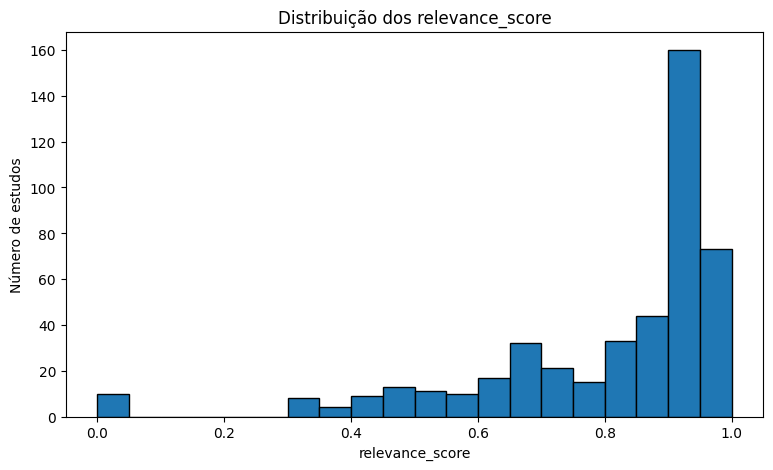

Tipos de estudo:


,n
study_type,
PRIMARY_DEFENSE,92
PRIMARY_ATTACK,83
DETECTION,64
APPLICATION_SECURITY,60
BENCHMARK_EVALUATION,55
PRIMARY_ATTACK_AND_DEFENSE,23
SURVEY,20
RED_TEAMING,20
OTHER,18


Contextos:


,n
contexts,
GENERAL_LLM,420
CYBERSECURITY,198
UNTRUSTED_INPUT,89
EXTERNAL_CONTENT,82
AGENT,80
MULTIMODAL,58
OTHER,52
CHATBOT,51
RAG,47


Contribuições:


,n
contribution_types,
EVALUATION,386
DEFENSE,212
FRAMEWORK,200
ATTACK,168
MITIGATION,166
DETECTION,138
PREVENTION,62
BENCHMARK,58
RED_TEAMING,45


In [67]:
evaluated_studies = studies.loc[
    studies["screening_status"] == "EVALUATED"
].copy()

print("Estudos únicos avaliados:", len(evaluated_studies))

if len(evaluated_studies):
    display(
        evaluated_studies["relevance_score"]
        .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
        .to_frame("relevance_score")
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(
        evaluated_studies["relevance_score"].dropna(),
        bins=[i / 20 for i in range(21)],
        edgecolor="black",
    )
    ax.set_title("Distribuição dos relevance_score")
    ax.set_xlabel("relevance_score")
    ax.set_ylabel("Número de estudos")
    plt.show()

    print("Tipos de estudo:")
    display(
        evaluated_studies["study_type"]
        .replace("", "UNCLASSIFIED")
        .value_counts()
        .to_frame("n")
    )

    print("Contextos:")
    display(explode_counts(combined.loc[combined["screening_status"]=="EVALUATED"], "contexts").to_frame("n"))

    print("Contribuições:")
    display(explode_counts(combined.loc[combined["screening_status"]=="EVALUATED"], "contribution_types").to_frame("n"))

## Simular candidatos para leitura integral

In [68]:
full_text_candidates = (
    evaluated_studies.loc[
        (evaluated_studies["hard_exclude"] == False)
        & (evaluated_studies["relevance_score"] >= FULL_TEXT_THRESHOLD)
    ]
    .sort_values(["relevance_score", "confidence"], ascending=[False, False])
    .copy()
)

gray_zone = (
    evaluated_studies.loc[
        (evaluated_studies["hard_exclude"] == False)
        & (
            evaluated_studies["relevance_score"].between(
                FULL_TEXT_THRESHOLD - GRAY_ZONE_MARGIN,
                FULL_TEXT_THRESHOLD + GRAY_ZONE_MARGIN,
                inclusive="both",
            )
            | (evaluated_studies["confidence"].fillna(0) < LOW_CONFIDENCE_THRESHOLD)
        )
    ]
    .sort_values(["relevance_score", "confidence"], ascending=[False, True])
    .copy()
)

print(
    f"Candidatos provisórios (score >= {FULL_TEXT_THRESHOLD:.2f}):",
    len(full_text_candidates),
)
print("Zona de revisão manual:", len(gray_zone))

display(
    full_text_candidates[
        [
            "title",
            "sources",
            "year",
            "doi",
            "relevance_score",
            "confidence",
            "study_type",
            "contexts",
            "contribution_types",
            "reason",
        ]
    ].head(50)
)

Candidatos provisórios (score >= 0.85): 277
Zona de revisão manual: 103


,title,sources,year,doi,relevance_score,confidence,study_type,contexts,contribution_types,reason
223,RIPE-II: Retrieval In-Place Poisoning Evaluation with Indirect Injections,[IEEE],2026,10.1109/dsn69566.2026.00078,0.99,1.00,BENCHMARK_EVALUATION,"[DOCUMENT_PROCESSING, EXTERNAL_CONTENT, GENERAL_LLM, MULTIMODAL, RAG, UNTRUSTED_INPUT, WEB]","[ATTACK, BENCHMARK, DATASET, EVALUATION, FRAMEWORK]",O trabalho é diretamente centrado em indirect prompt injection em RAG sob um modelo realista de envenenamento de con...
459,"Prompt Injection as a Systemic Vulnerability in LLM-Based Tools: Threat Models, Empirical Analysis, and Mitigation S...",[IEEE],2026,10.1109/sera69989.2026.11618608,0.99,1.00,PRIMARY_ATTACK_AND_DEFENSE,"[AGENT, EXTERNAL_CONTENT, GENERAL_LLM, RAG, UNTRUSTED_INPUT]","[ATTACK, DEFENSE, EVALUATION, FRAMEWORK, MITIGATION, TAXONOMY]","Prompt injection é o foco central, com modelo de ameaça para entradas de usuário, retrieval, ferramentas e memória, ..."
119,TrustTrace: Provenance-Aware Tracing of Indirect Prompt Injection Propagation in LLM-Assisted Learning Workflows,[IEEE],2026,10.1109/access.2026.3726909,0.99,0.99,DETECTION,"[EXTERNAL_CONTENT, GENERAL_LLM, RAG, UNTRUSTED_INPUT]","[DETECTION, EVALUATION, FORENSICS, FRAMEWORK]",O trabalho é diretamente centrado em indirect prompt injection e rastreia sua propagação de fontes e contextos recup...
292,DarkCite: Unveiling Authority Bias as Implicit Rag Jailbreak Attacks,[IEEE],2026,10.1109/icassp55912.2026.11463457,0.99,0.99,PRIMARY_ATTACK_AND_DEFENSE,"[GENERAL_LLM, RAG]","[ATTACK, DEFENSE, EVALUATION, MITIGATION]","DarkCite propõe um jailbreak black-box baseado em autoridade e citações fabricadas, interpretado como forma de RAG i..."
312,Zero-Shot Prompt Injection Detection via N-gram Pooling of Token-Level Hidden States,[IEEE],2026,10.1109/iccsdfai70505.2026.11647875,0.99,0.99,DETECTION,"[CYBERSECURITY, DOCUMENT_PROCESSING, EXTERNAL_CONTENT, GENERAL_LLM, RAG, UNTRUSTED_INPUT]","[DETECTION, EVALUATION]",O trabalho é diretamente dedicado à detecção de prompt injection embutido em documentos recuperados por pipelines RA...
342,Visual and Structural Prompt Injection in Medical Rag Systems: a Comparative Robustness Analysis,[IEEE],2026,10.1109/ichora69329.2026.11536987,0.99,0.99,PRIMARY_ATTACK,"[DOCUMENT_PROCESSING, DOCUMENT_UNDERSTANDING, EXTERNAL_CONTENT, MULTIMODAL, RAG, UNTRUSTED_INPUT]","[ATTACK, EVALUATION]","Investiga diretamente prompt injection indireta visual e estrutural em RAG médico, incluindo white-text, microtipogr..."
408,Security and Assurance Evaluation of RAG-Based AI Assistants in Learning Management Systems: A Pilot Study on Prompt...,[IEEE],2026,10.1109/isitia71267.2026.11642234,0.99,0.99,BENCHMARK_EVALUATION,"[CYBERSECURITY, DOCUMENT_PROCESSING, EXTERNAL_CONTENT, GENERAL_LLM, RAG, UNTRUSTED_INPUT]","[ATTACK, BENCHMARK, DATASET, DEFENSE, EVALUATION, MITIGATION]","O estudo avalia diretamente prompt injection direta e indireta, leakage e poisoning em um assistente RAG que process..."
445,Disrupting Large Language Models with Hidden Prompt Injection Attacks Embedded in HTML Pages,[IEEE],2025,10.1109/optim-acemp62776.2025.11075247,0.99,0.99,PRIMARY_ATTACK_AND_DEFENSE,"[EMAIL, EXTERNAL_CONTENT, GENERAL_LLM, HTML, INFORMATION_EXTRACTION, UNTRUSTED_INPUT, WEB]","[ATTACK, BENCHMARK, DATASET, DEFENSE, EVALUATION, MITIGATION]",O estudo investiga diretamente prompt injection oculto em HTML durante extração de informações de fontes web e e-mai...
456,Get My Drift? Catching LLM Task Drift with Activation Deltas,[IEEE],2025,10.1109/satml64287.2025.00011,0.99,0.99,DETECTION,"[EMAIL, EXTERNAL_CONTENT, GENERAL_LLM, RAG, UNTRUSTED_INPUT]","[DATASET, DEFENSE, DETECTION, EVALUATION, FRAMEWORK]",O artigo aborda diretamente prompt injection causada por instruções presentes em dados externos não confiáveis de ap...
464,Veritas: Dynamic Evaluation Framework for Rag Systems' Defense Against Prompt Injection Attacks,[IEEE],2026,10.1109/smartnets69662.2026.11604866,0.99,0.99,BENCHMAR

## Ranking atual

In [69]:
top_ranked = (
    evaluated_studies.loc[evaluated_studies["hard_exclude"] == False]
    .sort_values(["relevance_score", "confidence"], ascending=[False, False])
)

display(
    top_ranked[
        [
            "title",
            "sources",
            "year",
            "doi",
            "relevance_score",
            "confidence",
            "study_type",
            "contexts",
            "contribution_types",
            "reason",
        ]
    ].head(30)
)

,title,sources,year,doi,relevance_score,confidence,study_type,contexts,contribution_types,reason
223,RIPE-II: Retrieval In-Place Poisoning Evaluation with Indirect Injections,[IEEE],2026,10.1109/dsn69566.2026.00078,0.99,1.00,BENCHMARK_EVALUATION,"[DOCUMENT_PROCESSING, EXTERNAL_CONTENT, GENERAL_LLM, MULTIMODAL, RAG, UNTRUSTED_INPUT, WEB]","[ATTACK, BENCHMARK, DATASET, EVALUATION, FRAMEWORK]",O trabalho é diretamente centrado em indirect prompt injection em RAG sob um modelo realista de envenenamento de con...
459,"Prompt Injection as a Systemic Vulnerability in LLM-Based Tools: Threat Models, Empirical Analysis, and Mitigation S...",[IEEE],2026,10.1109/sera69989.2026.11618608,0.99,1.00,PRIMARY_ATTACK_AND_DEFENSE,"[AGENT, EXTERNAL_CONTENT, GENERAL_LLM, RAG, UNTRUSTED_INPUT]","[ATTACK, DEFENSE, EVALUATION, FRAMEWORK, MITIGATION, TAXONOMY]","Prompt injection é o foco central, com modelo de ameaça para entradas de usuário, retrieval, ferramentas e memória, ..."
119,TrustTrace: Provenance-Aware Tracing of Indirect Prompt Injection Propagation in LLM-Assisted Learning Workflows,[IEEE],2026,10.1109/access.2026.3726909,0.99,0.99,DETECTION,"[EXTERNAL_CONTENT, GENERAL_LLM, RAG, UNTRUSTED_INPUT]","[DETECTION, EVALUATION, FORENSICS, FRAMEWORK]",O trabalho é diretamente centrado em indirect prompt injection e rastreia sua propagação de fontes e contextos recup...
292,DarkCite: Unveiling Authority Bias as Implicit Rag Jailbreak Attacks,[IEEE],2026,10.1109/icassp55912.2026.11463457,0.99,0.99,PRIMARY_ATTACK_AND_DEFENSE,"[GENERAL_LLM, RAG]","[ATTACK, DEFENSE, EVALUATION, MITIGATION]","DarkCite propõe um jailbreak black-box baseado em autoridade e citações fabricadas, interpretado como forma de RAG i..."
312,Zero-Shot Prompt Injection Detection via N-gram Pooling of Token-Level Hidden States,[IEEE],2026,10.1109/iccsdfai70505.2026.11647875,0.99,0.99,DETECTION,"[CYBERSECURITY, DOCUMENT_PROCESSING, EXTERNAL_CONTENT, GENERAL_LLM, RAG, UNTRUSTED_INPUT]","[DETECTION, EVALUATION]",O trabalho é diretamente dedicado à detecção de prompt injection embutido em documentos recuperados por pipelines RA...
342,Visual and Structural Prompt Injection in Medical Rag Systems: a Comparative Robustness Analysis,[IEEE],2026,10.1109/ichora69329.2026.11536987,0.99,0.99,PRIMARY_ATTACK,"[DOCUMENT_PROCESSING, DOCUMENT_UNDERSTANDING, EXTERNAL_CONTENT, MULTIMODAL, RAG, UNTRUSTED_INPUT]","[ATTACK, EVALUATION]","Investiga diretamente prompt injection indireta visual e estrutural em RAG médico, incluindo white-text, microtipogr..."
408,Security and Assurance Evaluation of RAG-Based AI Assistants in Learning Management Systems: A Pilot Study on Prompt...,[IEEE],2026,10.1109/isitia71267.2026.11642234,0.99,0.99,BENCHMARK_EVALUATION,"[CYBERSECURITY, DOCUMENT_PROCESSING, EXTERNAL_CONTENT, GENERAL_LLM, RAG, UNTRUSTED_INPUT]","[ATTACK, BENCHMARK, DATASET, DEFENSE, EVALUATION, MITIGATION]","O estudo avalia diretamente prompt injection direta e indireta, leakage e poisoning em um assistente RAG que process..."
445,Disrupting Large Language Models with Hidden Prompt Injection Attacks Embedded in HTML Pages,[IEEE],2025,10.1109/optim-acemp62776.2025.11075247,0.99,0.99,PRIMARY_ATTACK_AND_DEFENSE,"[EMAIL, EXTERNAL_CONTENT, GENERAL_LLM, HTML, INFORMATION_EXTRACTION, UNTRUSTED_INPUT, WEB]","[ATTACK, BENCHMARK, DATASET, DEFENSE, EVALUATION, MITIGATION]",O estudo investiga diretamente prompt injection oculto em HTML durante extração de informações de fontes web e e-mai...
456,Get My Drift? Catching LLM Task Drift with Activation Deltas,[IEEE],2025,10.1109/satml64287.2025.00011,0.99,0.99,DETECTION,"[EMAIL, EXTERNAL_CONTENT, GENERAL_LLM, RAG, UNTRUSTED_INPUT]","[DATASET, DEFENSE, DETECTION, EVALUATION, FRAMEWORK]",O artigo aborda diretamente prompt injection causada por instruções presentes em dados externos não confiáveis de ap...
464,Veritas: Dynamic Evaluation Framework for Rag Systems' Defense Against Prompt Injection Attacks,[IEEE],2026,10.1109/smartnets69662.2026.11604866,0.99,0.99,BENCHMAR

## Pendências

In [70]:
pending = (
    studies.loc[studies["screening_status"] == "PENDING"]
    .sort_values(["sources", "title"])
    .copy()
)

print("Estudos únicos pendentes:", len(pending))
display(pending[["title", "sources", "year", "doi", "url"]].head(50))

TypeError: unhashable type: 'list'

## Resumo por base

In [ ]:
rows = []

for database, group in combined.groupby("database"):
    eg = group.loc[group["screening_status"] == "EVALUATED"]
    scores = pd.to_numeric(eg["relevance_score"], errors="coerce")

    rows.append({
        "database": database,
        "records_total": len(group),
        "evaluated": len(eg),
        "pending": (group["screening_status"] == "PENDING").sum(),
        "hard_exclude": eg["hard_exclude"].fillna(False).sum() if len(eg) else 0,
        "mean_score": scores.mean() if len(eg) else None,
        "median_score": scores.median() if len(eg) else None,
        "score_ge_threshold": (scores >= FULL_TEXT_THRESHOLD).sum() if len(eg) else 0,
    })

database_summary = pd.DataFrame(rows)
display(database_summary)

## Exportar arquivos

In [ ]:
threshold_tag = str(FULL_TEXT_THRESHOLD).replace(".", "_")

combined.to_csv(
    OUTPUT_DIR / "all_records_with_screening.csv",
    index=False,
    encoding="utf-8-sig",
)

studies.to_csv(
    OUTPUT_DIR / "master_studies_deduplicated.csv",
    index=False,
    encoding="utf-8-sig",
)

top_ranked.to_csv(
    OUTPUT_DIR / "ranked_evaluated_studies.csv",
    index=False,
    encoding="utf-8-sig",
)

full_text_candidates.to_csv(
    OUTPUT_DIR / f"full_text_candidates_{threshold_tag}.csv",
    index=False,
    encoding="utf-8-sig",
)

gray_zone.to_csv(
    OUTPUT_DIR / f"manual_review_zone_{threshold_tag}.csv",
    index=False,
    encoding="utf-8-sig",
)

pending.to_csv(
    OUTPUT_DIR / "pending_screening.csv",
    index=False,
    encoding="utf-8-sig",
)

duplicates.to_csv(
    OUTPUT_DIR / "possible_duplicates.csv",
    index=False,
    encoding="utf-8-sig",
)

invalid_scores.to_csv(
    OUTPUT_DIR / "screening_validation_issues.csv",
    index=False,
    encoding="utf-8-sig",
)

database_summary.to_csv(
    OUTPUT_DIR / "summary_by_database.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Arquivos gerados em:", OUTPUT_DIR.resolve())
for p in sorted(OUTPUT_DIR.glob("*.csv")):
    print(" -", p.name)

## Uso metodológico

Enquanto o screening estiver incompleto, use o notebook apenas para:

- acompanhar quantos estudos já foram avaliados;
- observar a distribuição dos scores;
- verificar erros de cálculo;
- identificar duplicatas;
- observar tipos de estudos, contextos e contribuições;
- experimentar diferentes pontos de corte.

O corte definitivo para leitura integral deve ser definido somente depois que as bases planejadas tiverem sido processadas.

O arquivo central para a fase seguinte será:

`analysis_outputs/master_studies_deduplicated.csv`

In [ ]:
# ============================================================
# GERAR CSV FINAL CONSOLIDADO
# ============================================================

final_df = studies.copy()

# ------------------------------------------------------------
# 1. Criar status de decisão provisória
# ------------------------------------------------------------

def classify_screening(row):
    if row["screening_status"] == "PENDING":
        return "PENDING"

    if row["hard_exclude"] == True:
        return "HARD_EXCLUDE"

    score = row["relevance_score"]

    if pd.isna(score):
        return "PENDING"

    if score >= FULL_TEXT_THRESHOLD:
        return "FULL_TEXT_CANDIDATE"

    if score >= (FULL_TEXT_THRESHOLD - GRAY_ZONE_MARGIN):
        return "MANUAL_REVIEW"

    return "BELOW_THRESHOLD"


final_df["selection_status"] = final_df.apply(
    classify_screening,
    axis=1
)


# ------------------------------------------------------------
# 2. Criar ranking
# ------------------------------------------------------------

# Ranking somente entre estudos avaliados e não hard-excluded
eligible_mask = (
    (final_df["screening_status"] == "EVALUATED")
    & (final_df["hard_exclude"] == False)
)

final_df["relevance_rank"] = pd.NA

final_df.loc[
    eligible_mask,
    "relevance_rank"
] = (
    final_df.loc[
        eligible_mask,
        "relevance_score"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype("Int64")
)


# ------------------------------------------------------------
# 3. Converter campos que são listas para texto legível no CSV
# ------------------------------------------------------------

def list_to_text(value):
    if isinstance(value, list):
        return "; ".join(map(str, value))
    return value


for column in [
    "sources",
    "contexts",
    "contribution_types",
]:
    if column in final_df.columns:
        final_df[column] = final_df[column].apply(
            list_to_text
        )


# ------------------------------------------------------------
# 4. Organizar as colunas
# ------------------------------------------------------------

preferred_columns = [
    "relevance_rank",
    "selection_status",
    "relevance_score",
    "confidence",

    "title",
    "authors",
    "year",
    "doi",
    "url",
    "venue",

    "sources",
    "source_count",

    "study_type",
    "contribution_types",
    "contexts",

    "hard_exclude",
    "screening_status",

    "n_evaluations",
    "score_range_if_repeated",

    "reason",
    "abstract",

    "study_key",
]

# Mantém somente colunas existentes
preferred_columns = [
    col
    for col in preferred_columns
    if col in final_df.columns
]

final_df = final_df[
    preferred_columns
].copy()


# ------------------------------------------------------------
# 5. Definir ordem dos status
# ------------------------------------------------------------

status_order = {
    "FULL_TEXT_CANDIDATE": 1,
    "MANUAL_REVIEW": 2,
    "BELOW_THRESHOLD": 3,
    "HARD_EXCLUDE": 4,
    "PENDING": 5,
}

final_df["_status_order"] = (
    final_df["selection_status"]
    .map(status_order)
    .fillna(99)
)


# ------------------------------------------------------------
# 6. Ordenar
# ------------------------------------------------------------

final_df = (
    final_df
    .sort_values(
        by=[
            "_status_order",
            "relevance_score",
            "confidence",
        ],
        ascending=[
            True,
            False,
            False,
        ],
        na_position="last",
    )
    .drop(
        columns="_status_order"
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. Exportar
# ------------------------------------------------------------

output_file = (
    OUTPUT_DIR
    / "FINAL_screening_studies.csv"
)

final_df.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig",
)


# ------------------------------------------------------------
# 8. Mostrar resumo
# ------------------------------------------------------------

print("=" * 70)
print("CSV FINAL GERADO")
print("=" * 70)

print(f"Arquivo: {output_file.resolve()}")
print(f"Total de estudos únicos: {len(final_df)}")

print("\nSituação:")

display(
    final_df[
        "selection_status"
    ]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="n")
)

print(
    "\nCandidatos para leitura integral:",
    (
        final_df["selection_status"]
        == "FULL_TEXT_CANDIDATE"
    ).sum()
)

print(
    "Revisão manual:",
    (
        final_df["selection_status"]
        == "MANUAL_REVIEW"
    ).sum()
)

print(
    "Abaixo do corte:",
    (
        final_df["selection_status"]
        == "BELOW_THRESHOLD"
    ).sum()
)

print(
    "Hard exclude:",
    (
        final_df["selection_status"]
        == "HARD_EXCLUDE"
    ).sum()
)

print(
    "Ainda pendentes:",
    (
        final_df["selection_status"]
        == "PENDING"
    ).sum()
)

print("\nPrimeiros registros:")

display(
    final_df[
        [
            "relevance_rank",
            "selection_status",
            "relevance_score",
            "confidence",
            "title",
            "sources",
            "study_type",
        ]
    ].head(20)
)

CSV FINAL GERADO
Arquivo: C:\Users\Marcos Rocha\Downloads\prompt-injection-review\NEW\analysis_outputs\FINAL_screening_studies.csv
Total de estudos únicos: 552

Situação:


,status,n
0,FULL_TEXT_CANDIDATE,243
1,PENDING,190
2,BELOW_THRESHOLD,98
3,MANUAL_REVIEW,12
4,HARD_EXCLUDE,9



Candidatos para leitura integral: 243
Revisão manual: 12
Abaixo do corte: 98
Hard exclude: 9
Ainda pendentes: 190

Primeiros registros:


,relevance_rank,selection_status,relevance_score,confidence,title,sources,study_type
0,1,FULL_TEXT_CANDIDATE,0.99,0.99,TrustTrace: Provenance-Aware Tracing of Indirect Prompt Injection Propagation in LLM-Assisted Learning Workflows,IEEE,DETECTION
1,1,FULL_TEXT_CANDIDATE,0.99,0.99,DarkCite: Unveiling Authority Bias as Implicit Rag Jailbreak Attacks,IEEE,PRIMARY_ATTACK_AND_DEFENSE
2,1,FULL_TEXT_CANDIDATE,0.99,0.99,Visual and Structural Prompt Injection in Medical Rag Systems: a Comparative Robustness Analysis,IEEE,PRIMARY_ATTACK
3,1,FULL_TEXT_CANDIDATE,0.99,0.99,Disrupting Large Language Models with Hidden Prompt Injection Attacks Embedded in HTML Pages,IEEE,PRIMARY_ATTACK_AND_DEFENSE
4,1,FULL_TEXT_CANDIDATE,0.99,0.99,Get My Drift? Catching LLM Task Drift with Activation Deltas,IEEE,DETECTION
5,1,FULL_TEXT_CANDIDATE,0.99,0.98,Zero-Shot Tokenizer Transfer for Targeted Attacks on Retrieval-Augmented Generation,IEEE,PRIMARY_ATTACK
6,7,FULL_TEXT_CANDIDATE,0.96,0.99,Hold the Prompt (HODPOT): Defense Design for Securing the System Prompt of LLM Agents,IEEE,PRIMARY_DEFENSE
7,7,FULL_TEXT_CANDIDATE,0.96,0.99,A Systematic Literature Review of Prompt Injection Attacks in LLM-Integrated Systems,IEEE,REVIEW
8,7,FULL_TEXT_CANDIDATE,0.96,0.99,Automatically Generated Multi-Agent Framework for Jailbreaking Large Language Models,IEEE,RED_TEAMING
9,7,FULL_TEXT_CANDIDATE,0.96,0.99,Securing Vision-Language Models with a Robust Encoder Against Jailbreak and Adversarial Attacks,IEEE,PRIMARY_DEFENSE
